In [1]:
from pytspl import list_datasets, load_dataset, SCPlot
import numpy as np
import matplotlib.pyplot as plt
from pytspl.embeddings.k_simplex2vec import cell2vec
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

list_datasets()

['anaheim',
 'barcelona',
 'chicago-regional',
 'chicago-sketch',
 'goldcoast',
 'siouxfalls',
 'test_dataset',
 'winnipeg',
 'paper',
 'forex',
 'lastfm-1k-artist',
 'webkb-cornell',
 'webkb-texas',
 'webkb-wisconsin',
 'wsn']

In [2]:
dataset = "webkb-cornell"
cc, coordinates, flow = load_dataset(dataset=dataset, only_sc=False)

k = 1

emb_dim = 20
walk_length = 10
number_walks = 10
scheme = "uniform"          
laziness = None            
epochs = 10
seed = 0

embeddings = cell2vec(
    cc=cc,
    k=k,
    emb_dim=emb_dim,
    walk_length=walk_length,
    number_walks=number_walks,
    scheme=scheme,
    laziness=laziness,
    epochs=epochs,
    seed=seed,
    model_filename=None,    # don't bother saving model for now
)

print("Embeddings shape:", embeddings.shape)

Num. of nodes: 183
Num. of edges: 280
Num. of triangles: 98
Coordinates: 183
Flow: 0
Embeddings shape: (280, 20)


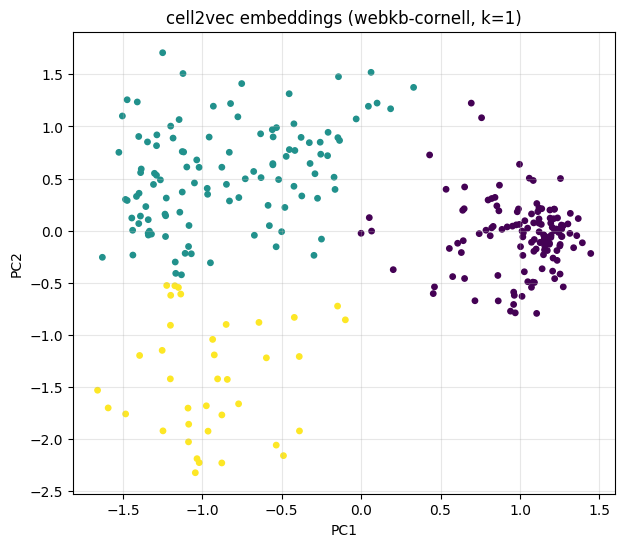

In [3]:
n_clusters = 3  
kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
labels = kmeans.fit_predict(embeddings)

pca = PCA(n_components=2, random_state=seed)
emb_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, s=15)
plt.title(f"cell2vec embeddings ({dataset}, k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

In [4]:
for k in [1, 2]:
    try:
        emb = cell2vec(
            cc=cc,
            k=k,
            emb_dim=20,
            walk_length=10,
            number_walks=10,
            scheme="uniform-multicount",
            laziness=None,
            epochs=10,
            seed=0,
            model_filename=None,
        )
        print(f"k={k}: emb.shape = {emb.shape}")
    except Exception as e:
        print(f"k={k}: failed with {e}")

k=1: emb.shape = (280, 20)
k=2: emb.shape = (98, 20)


In [6]:
emb_lazy = cell2vec(
    cc=cc,
    k=1,
    emb_dim=16,
    walk_length=20,
    number_walks=10,
    scheme="uniform-lazy",
    laziness=0.5,
    epochs=5,
    seed=0,
    model_filename=None,
)
print("Lazy walk embeddings shape:", emb_lazy.shape)

Lazy walk embeddings shape: (280, 16)


In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from pytspl.simplicial_complex import SCBuilder
from pytspl.embeddings.k_simplex2vec import cell2vec

# ------------------------------------------------------------
# 1. Build the same SBM graph she uses
# ------------------------------------------------------------
n = 20
q = 0.3
p = 0.8
probs = [[p, q, q],
         [q, p, q],
         [q, q, p]]

G = nx.generators.community.stochastic_block_model(
    [n, n, n],
    probs,
    seed=7,
)

# ------------------------------------------------------------
# 2. Build a simplicial complex using your SCBuilder
#    (equivalent to Gudhi SimplexTree + expansion(3))
# ------------------------------------------------------------
nodes = list(G.nodes())
edges = list(G.edges())

sc_builder = SCBuilder(
    nodes=nodes,
    edges=edges,
    node_features={},
    edge_features={},
)

# Build clique complex up to dimension 2
sc = sc_builder.to_simplicial_complex(condition="all")
print(
    f"There are {len(sc.nodes)} nodes, "
    f"{len(sc.edges)} edges, "
    f"{len(sc.triangles)} triangles."
)

There are 60 nodes, 795 edges, 3361 triangles.


In [28]:
from sklearn.cluster import KMeans

emb_dim = 30
k = 1          # 0 = nodes, 1 = edges, 2 = triangles
walk_length = 20
number_walks = 40

embeddings = cell2vec(
    cc=sc,
    k=k,
    emb_dim=emb_dim,
    walk_length=walk_length,
    number_walks=number_walks,
    scheme="uniform",
    laziness=None,
    seed=3,
)



Unique edge types (block pairs): [(0, 0), (0, 1), (0, 2), (1, 1), (1, 2), (2, 2)]
Number of edge types: 6


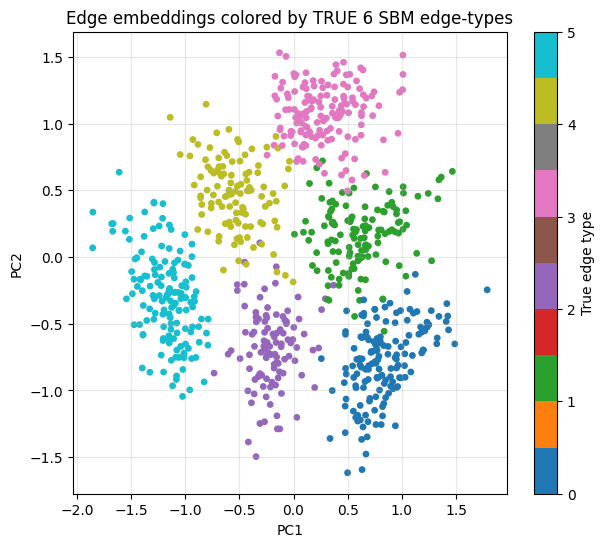

Adjusted Rand Index between KMeans(k=6) and true edge-types: 0.311


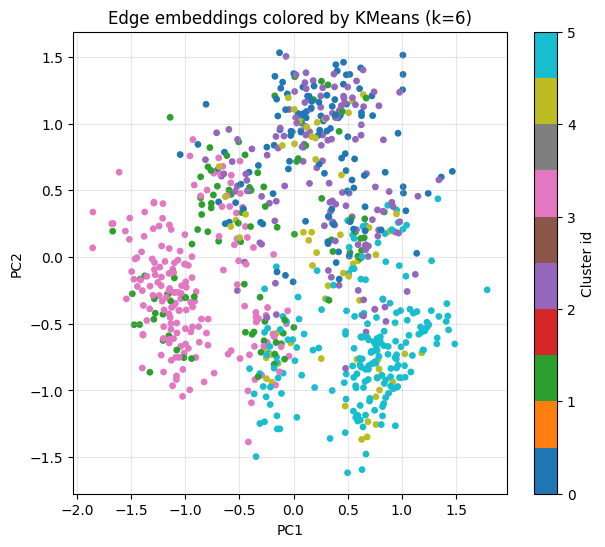

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# === you already have: G, sc, embeddings (k=1) ===

# ------------------------------------------------------------
# 3. Ground-truth edge classes (6 types)
# ------------------------------------------------------------
# node -> block index (0,1,2)
num_nodes = len(sc.nodes)   # should be 3*n
block = np.zeros(num_nodes, dtype=int)
block[n:2*n] = 1
block[2*n:3*n] = 2

edge_types = []
for (u, v) in sc.edges:
    a = block[u]
    b = block[v]
    # treat (a,b) same as (b,a)
    edge_types.append(tuple(sorted((a, b))))

# map each (block_a, block_b) pair to an integer 0..5
unique_types = sorted(set(edge_types))  # should have 6 entries
type_to_id = {t: i for i, t in enumerate(unique_types)}
y_true = np.array([type_to_id[t] for t in edge_types])  # shape (#edges,)

print("Unique edge types (block pairs):", unique_types)
print("Number of edge types:", len(unique_types))  # expect 6

# ------------------------------------------------------------
# 4. PCA to 2D
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=0)
emb_2d = pca.fit_transform(embeddings)

# ------------------------------------------------------------
# 5A. Plot colored by TRUE 6 classes (best to see structure)
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=y_true, s=15, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Edge embeddings colored by TRUE 6 SBM edge-types")
plt.grid(alpha=0.3)
plt.colorbar(scatter, label="True edge type")
plt.show()

# ------------------------------------------------------------
# 5B. KMeans with k=6, compare to ground truth
# ------------------------------------------------------------
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels_pred = kmeans.fit_predict(embeddings)

ari = adjusted_rand_score(y_true, labels_pred)
print(f"Adjusted Rand Index between KMeans(k=6) and true edge-types: {ari:.3f}")

plt.figure(figsize=(7, 6))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels_pred, s=15, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Edge embeddings colored by KMeans (k=6)")
plt.grid(alpha=0.3)
plt.colorbar(scatter, label="Cluster id")
plt.show()


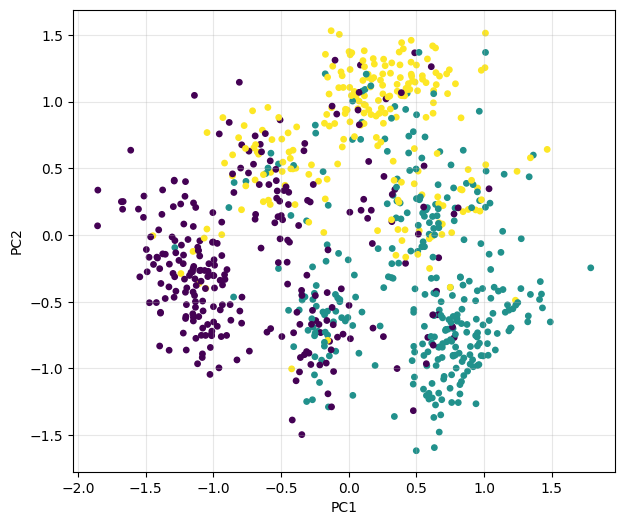

In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import AgglomerativeClustering

n_clusters = 3

# --- build k-NN graph on the embeddings ---
# k here is number of neighbors in the k-NN graph, not number of clusters
n_neighbors = 10
knn_graph = kneighbors_graph(
    embeddings,
    n_neighbors=n_neighbors,
    include_self=False,
    mode="connectivity",  # adjacency matrix
)

# --- clustering using k-NN connectivity ---
clustering = AgglomerativeClustering(
    n_clusters=n_clusters,
    connectivity=knn_graph,
    linkage="ward",
)
labels = clustering.fit_predict(embeddings)

# --- PCA for visualization (same as before) ---
pca = PCA(n_components=2, random_state=0)
emb_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()


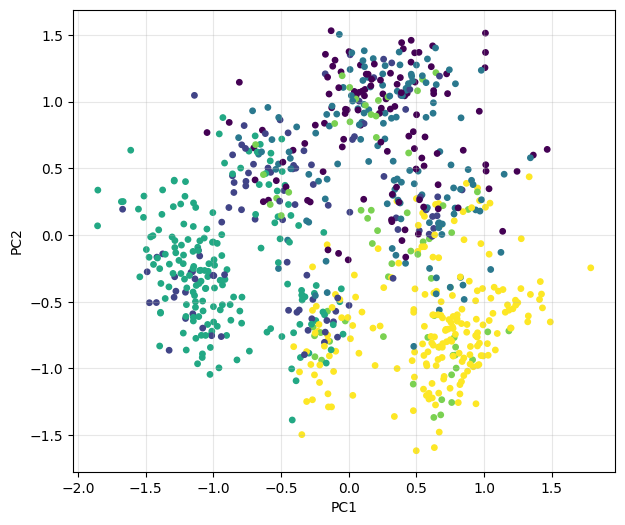

In [20]:
n_clusters = 6 
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(embeddings)

pca = PCA(n_components=2, random_state=0)
emb_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, s=15)
#plt.title(f"cell2vec embeddings ({dataset}, k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()